# 1. Data Handling

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set(style="whitegrid", palette="pastel", font_scale=1.1)

In [76]:
data = pd.read_csv('data.csv')

data.drop(columns='id', inplace=True)

In [77]:
data 

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [78]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [79]:
data.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


# 2.EDA

#### 2.1 Box and Count plots

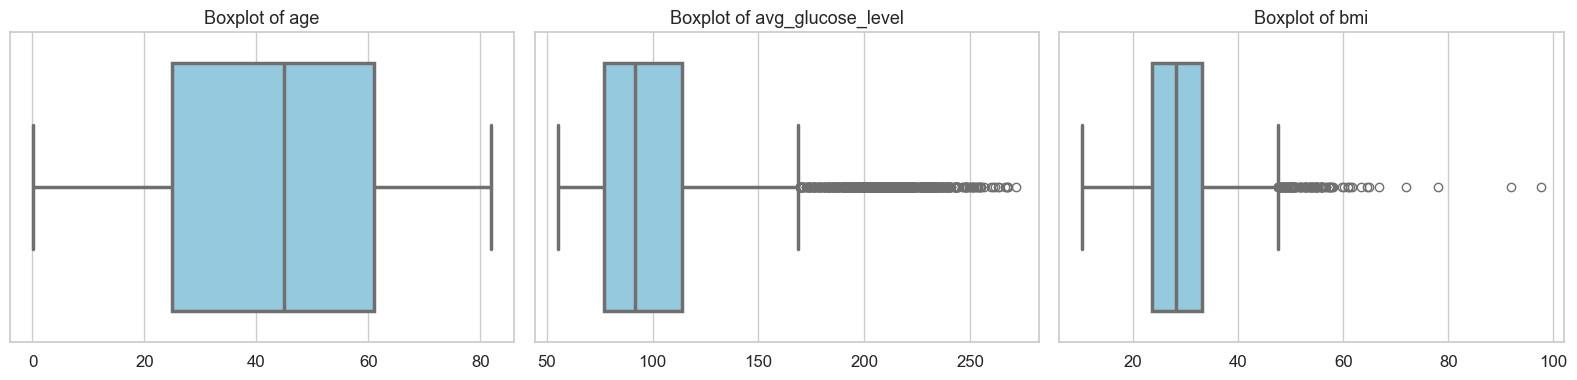

In [80]:
num_cols = ['age', 'avg_glucose_level', 'bmi']

plt.figure(figsize=(16, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=data, x=col, color="skyblue", linewidth=2.5)
    plt.title(f"Boxplot of {col}", fontsize=13)
    plt.xlabel("")
plt.tight_layout()
plt.show()

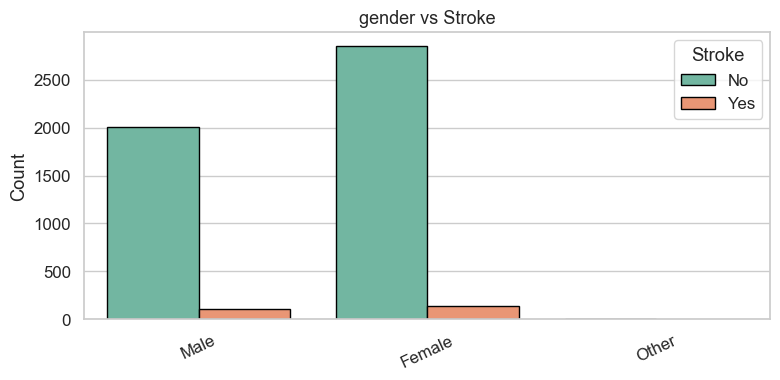

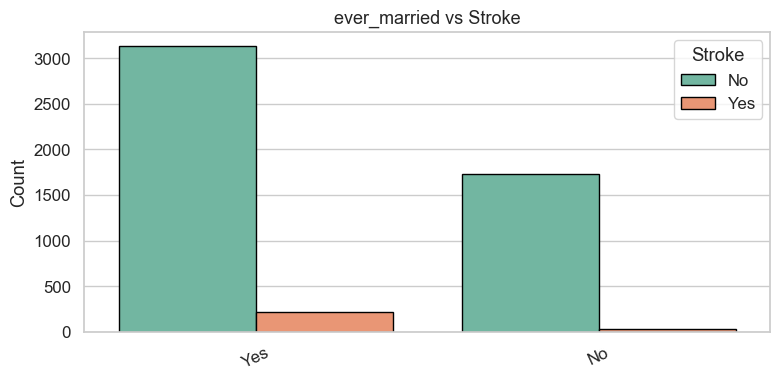

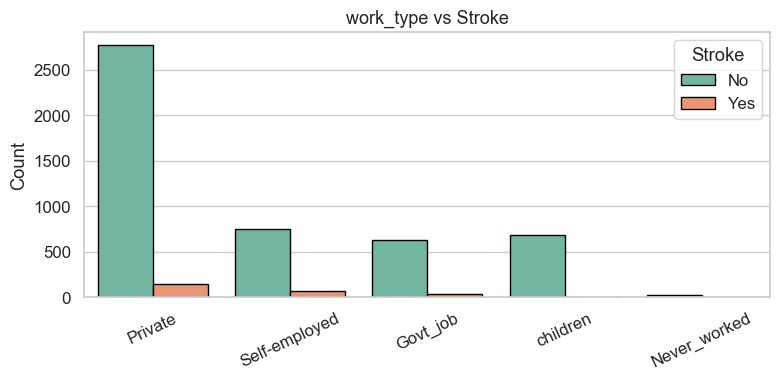

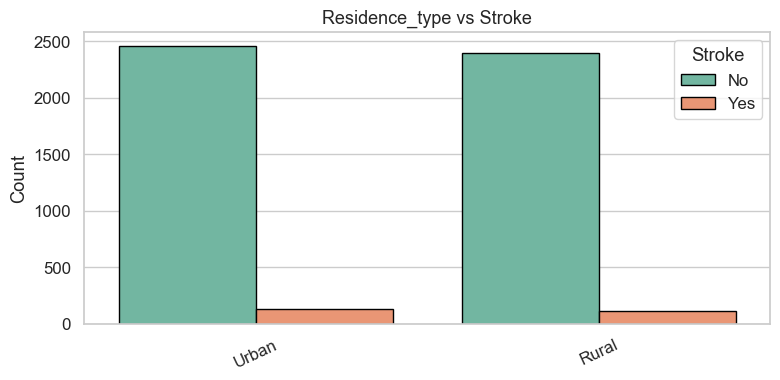

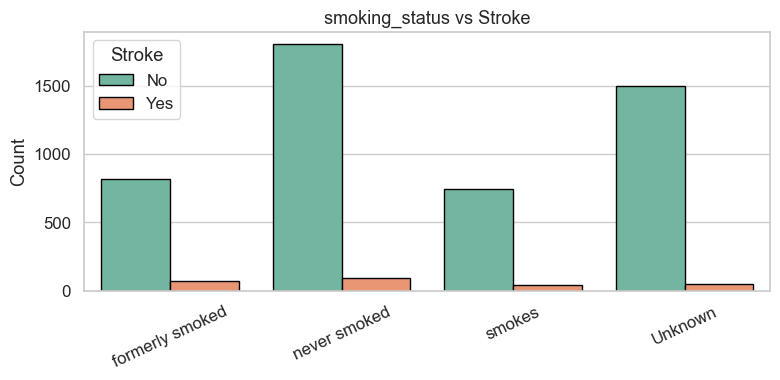

In [81]:
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=data, x=col, hue='stroke', palette="Set2", edgecolor="black")
    plt.title(f"{col} vs Stroke", fontsize=13)
    plt.xlabel("")
    plt.ylabel("Count")
    plt.xticks(rotation=25)
    plt.legend(title="Stroke", labels=["No", "Yes"])
    plt.tight_layout()
    plt.show()

 1. Boxplots (Outlier Detection)
- **Age**: The distribution of age appears fairly normal with no significant outliers. Most patients are between 20 and 80 years old.
- **Average Glucose Level**: The distribution is highly right-skewed with many outliers above 200. These may reflect medically relevant hyperglycemia cases. Consider log transformation or retaining them based on domain understanding.
- **BMI**: There are several outliers above 50, which could indicate severe obesity. These should be examined further but may be important for stroke risk prediction.

---

 2. Categorical Features vs Stroke
- **Gender**: Stroke occurs in both genders, with a slightly higher frequency among females.
- **Ever Married**: Patients who have been married are more likely to have had a stroke. This may be correlated with age.
- **Work Type**: Stroke is more common among patients in "Private", "Self-employed", and "Govt_job" work types.
- **Residence Type**: There is no significant difference in stroke frequency between urban and rural residents.
- **Smoking Status**: Stroke is more prevalent among patients who formerly smoked. The "Unknown" category may need special treatment during preprocessing.

---


#### 2.2 Heatmap

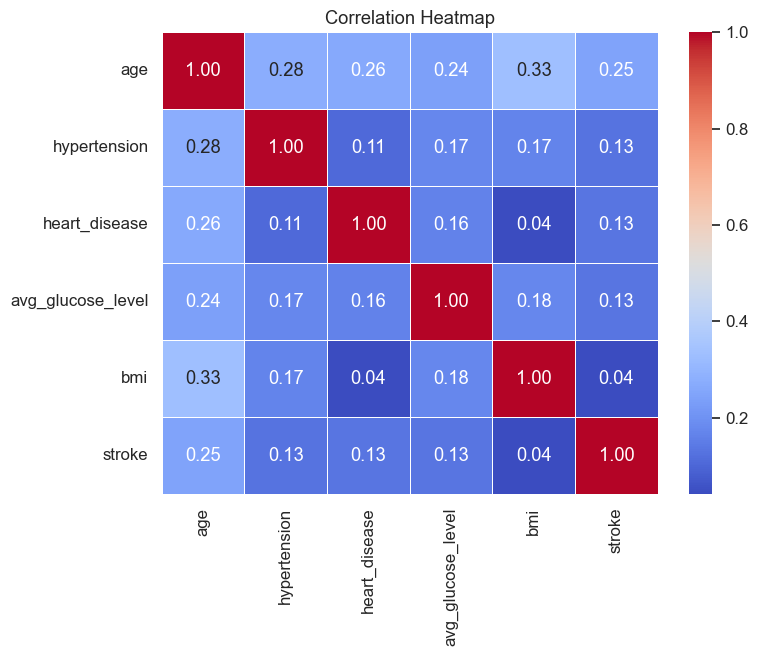

In [82]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

#### 2.3 Pairplot

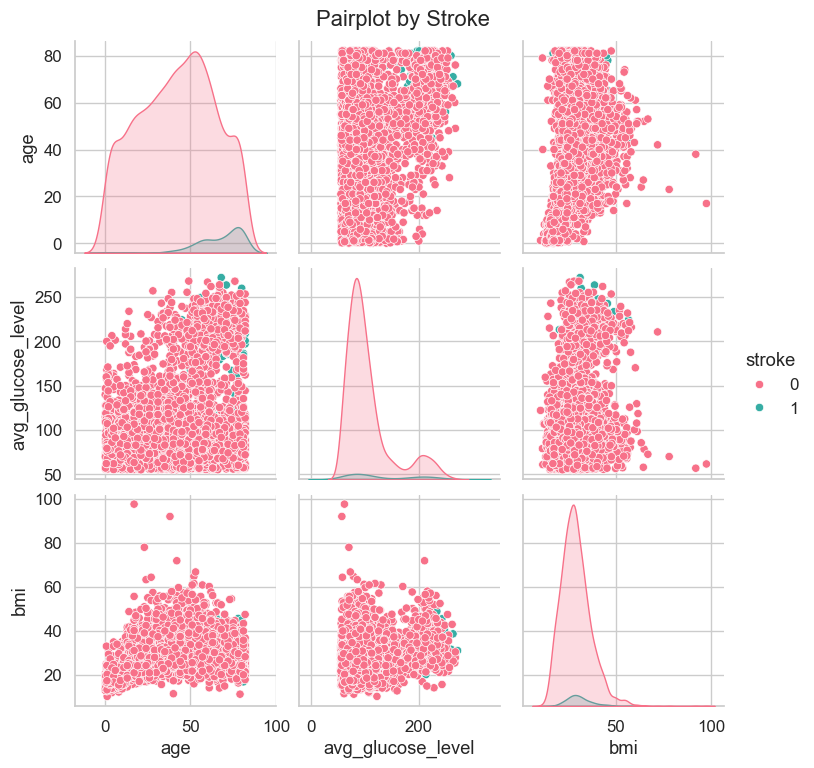

In [83]:
sns.pairplot(data[['age', 'avg_glucose_level', 'bmi', 'stroke']], hue='stroke', palette='husl')
plt.suptitle("Pairplot by Stroke", y=1.02)
plt.show()

/var/folders/z2/rmvv1qt937g_5bp6hf_qfy7h0000gn/T/ipykernel_6926/237507315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='stroke', y=col, data=data, palette='Set2', inner="quart")


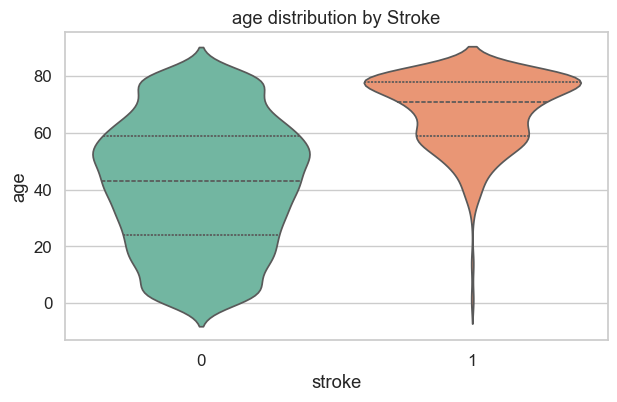

/var/folders/z2/rmvv1qt937g_5bp6hf_qfy7h0000gn/T/ipykernel_6926/237507315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='stroke', y=col, data=data, palette='Set2', inner="quart")


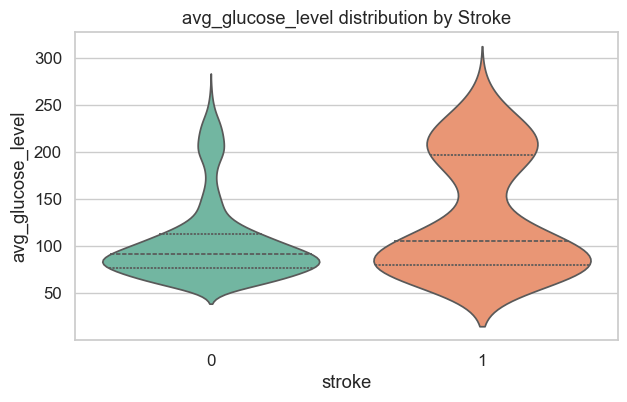

/var/folders/z2/rmvv1qt937g_5bp6hf_qfy7h0000gn/T/ipykernel_6926/237507315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='stroke', y=col, data=data, palette='Set2', inner="quart")


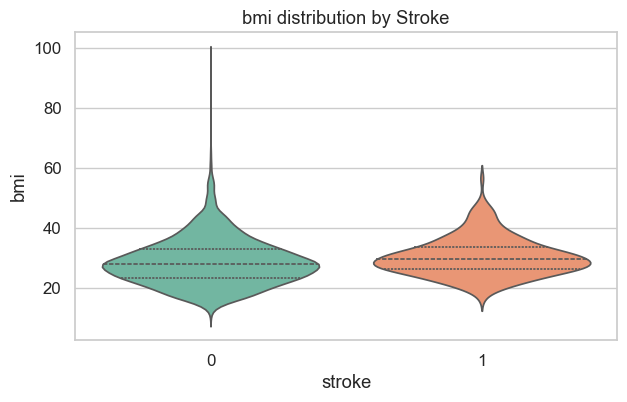

In [84]:
for col in ['age', 'avg_glucose_level', 'bmi']:
    plt.figure(figsize=(7,4))
    sns.violinplot(x='stroke', y=col, data=data, palette='Set2', inner="quart")
    plt.title(f"{col} distribution by Stroke")
    plt.show()


## EDA Summary & Key Insights

After performing exploratory data analysis (EDA) on the stroke prediction dataset, the following insights were gathered:

### 1. Data Quality
- Only one column (`bmi`) contains missing values (~4% of the data), which can be safely imputed using the median.
- No missing values in other columns.

### 2. Target Variable (`stroke`)
- The dataset is highly imbalanced: ~4.9% of patients experienced a stroke.
- This will require resampling techniques (e.g., SMOTE) or use of class weights during modeling.

### 3. Numerical Features
- `age` is fairly normally distributed; no significant outliers.
- `avg_glucose_level` is right-skewed with several high-value outliers. A log transformation is recommended.
- `bmi` has moderate right skew and a few outliers above 50.

### 4. Categorical Features
- **Gender**: Slightly more strokes among females.
- **Ever Married**: Strong correlation with stroke (likely due to age).
- **Work Type**: Higher stroke rates in "Private" and "Self-employed" groups.
- **Residence Type**: No significant difference between urban and rural populations.
- **Smoking Status**: Highest stroke occurrence in "formerly smoked" group. Special attention needed for "Unknown".

### 5. Visual Patterns
- Boxplots helped identify numerical outliers.
- Countplots showed clear group differences for some categorical variables.
- Next steps include encoding, scaling, and balancing the data to prepare it for modeling.

###  Conclusion:
The dataset provides rich medical and demographic information. Several predictors show potential influence on stroke occurrence, which will be leveraged during the modeling phase.


# 3. Data Engineering

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [86]:
data['bmi'].fillna(data['bmi'].median(), inplace=True) #fill bmi by median

data['avg_glucose_level'] = np.log1p(data['avg_glucose_level']) #log glucose

/var/folders/z2/rmvv1qt937g_5bp6hf_qfy7h0000gn/T/ipykernel_6926/1634231978.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['bmi'].fillna(data['bmi'].median(), inplace=True) #fill bmi by median


In [87]:
X = data.drop(columns='stroke')
y = data['stroke']

In [88]:
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
num_cols = ['age', 'avg_glucose_level', 'bmi']


In [89]:
num_pipe = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

# 4. Model Building/Evaluation

In [90]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [91]:
from sklearn.metrics            import classification_report, roc_auc_score, accuracy_score
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier
from xgboost                    import XGBClassifier
from catboost                   import CatBoostClassifier
from imblearn.over_sampling     import SMOTE


In [92]:
XtrainProc = preprocessor.fit_transform(Xtrain)
XtestProc = preprocessor.transform(Xtest)

smt = SMOTE(random_state=42)
XtrainBal, ytrainBal = smt.fit_resample(XtrainProc, ytrain)

In [93]:
models = {
    "LogisticRegression": LogisticRegression(
         class_weight='balanced', max_iter=1000, random_state=42),

    "RandomForest": RandomForestClassifier(
         class_weight=None, n_estimators=200, random_state=42),

    "XGBoost": XGBClassifier(
         scale_pos_weight=1,
         use_label_encoder=False,
         eval_metric='logloss',
         random_state=42),

    "CatBoost": CatBoostClassifier(
         auto_class_weights=None,
         iterations=200,
         verbose=False,
         random_state=42)
}

results = []
for name, model in models.items():
    model.fit(XtrainBal, ytrainBal)
    y_pred  = model.predict(XtestProc)
    y_proba = model.predict_proba(XtestProc)[:,1]
    
    report = classification_report(ytest, y_pred, output_dict=True, zero_division=0)
    auc    = roc_auc_score(ytest, y_proba)
    acc    = accuracy_score(ytest, y_pred)


    
    results.append({
        "Model":    name,
        "Accuracy": acc,
        "Precision": report['1']['precision'],
        "Recall":    report['1']['recall'],
        "F1-score":  report['1']['f1-score'],
        "ROC AUC":   auc
    })



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:10:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [94]:
df_results = pd.DataFrame(results).set_index("Model")
print(df_results)

                    Accuracy  Precision  Recall  F1-score   ROC AUC
Model                                                              
LogisticRegression  0.753425   0.141844    0.80  0.240964  0.843704
RandomForest        0.914873   0.137255    0.14  0.138614  0.776008
XGBoost             0.924658   0.200000    0.18  0.189474  0.798210
CatBoost            0.915851   0.153846    0.16  0.156863  0.787346


##  Model Comparison Results

| Model                 | Accuracy | Precision | Recall | F1-score | ROC AUC |
|-----------------------|---------:|----------:|-------:|---------:|--------:|
| Logistic Regression   |   0.7534 |    0.1418 |   0.80 |   0.2410 |  0.8437 |
| Random Forest         |   0.9149 |    0.1373 |   0.14 |   0.1386 |  0.7760 |
| XGBoost               |   0.9247 |    0.2000 |   0.18 |   0.1895 |  0.7982 |
| CatBoost              |   0.9159 |    0.1538 |   0.16 |   0.1569 |  0.7873 |

### Key Observations
- **Accuracy** is highest for **XGBoost** (92.47%) and **CatBoost** (91.59%), but high accuracy is influenced by the class imbalance.
- **Recall** (sensitivity to stroke cases) is best for **Logistic Regression** (0.80), meaning it catches most true stroke events.
- **Precision** is highest for **XGBoost** (0.20), so its positive predictions are more reliable.
- **F1-score** (balance of precision and recall) peaks with **Logistic Regression** (0.241) due to its strong recall, despite low precision.
- **ROC AUC** is highest for **Logistic Regression** (0.8437), indicating the best overall discrimination between classes.


According to Metric Results, it is decided to pick XGBoost due to its best values


# 5. Model Tuning(XGBoost)

In [95]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

In [103]:
xgb = XGBClassifier(
    scale_pos_weight=1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

param_dist = {
    'n_estimators':      randint(50, 500),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.2),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'gamma':             uniform(0, 5),
    'reg_alpha':         uniform(0, 1),
    'reg_lambda':        uniform(0, 1),
}

rs = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=200,
    scoring='f1',
    cv=10,
    verbose=0,
    random_state=42,
    n_jobs=-1
)


rs.fit(XtrainBal, ytrainBal)

print("Best params:", rs.best_params_)
print("Best F1 (CV):", rs.best_score_)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:28:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:28:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:28:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:28:24] WARN

Best params: {'colsample_bytree': np.float64(0.653085861527711), 'gamma': np.float64(0.7177118101969643), 'learning_rate': np.float64(0.19796395838536837), 'max_depth': 6, 'n_estimators': 424, 'reg_alpha': np.float64(0.1623818946623209), 'reg_lambda': np.float64(0.18834908376560144), 'subsample': np.float64(0.8923317899483505)}
Best F1 (CV): 0.9547562720082545


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:29:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [107]:
best_xgb = rs.best_estimator_
y_pred  = best_xgb.predict(XtestProc)
y_proba = best_xgb.predict_proba(XtestProc)[:,1]

print(classification_report(ytest, y_pred))
print("ROC AUC:", roc_auc_score(ytest, y_proba))


              precision    recall  f1-score   support

           0       0.96      0.96      0.96       972
           1       0.18      0.18      0.18        50

    accuracy                           0.92      1022
   macro avg       0.57      0.57      0.57      1022
weighted avg       0.92      0.92      0.92      1022

ROC AUC: 0.7746502057613169


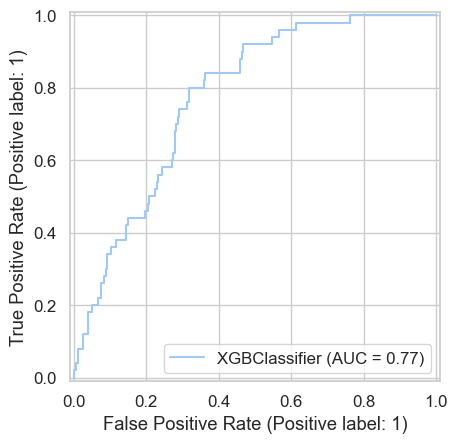

In [105]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(best_xgb, XtestProc, ytest)
plt.show()


/var/folders/z2/rmvv1qt937g_5bp6hf_qfy7h0000gn/T/ipykernel_6926/4039976535.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='importance', y='feature', data=feat_imp, palette='magma')


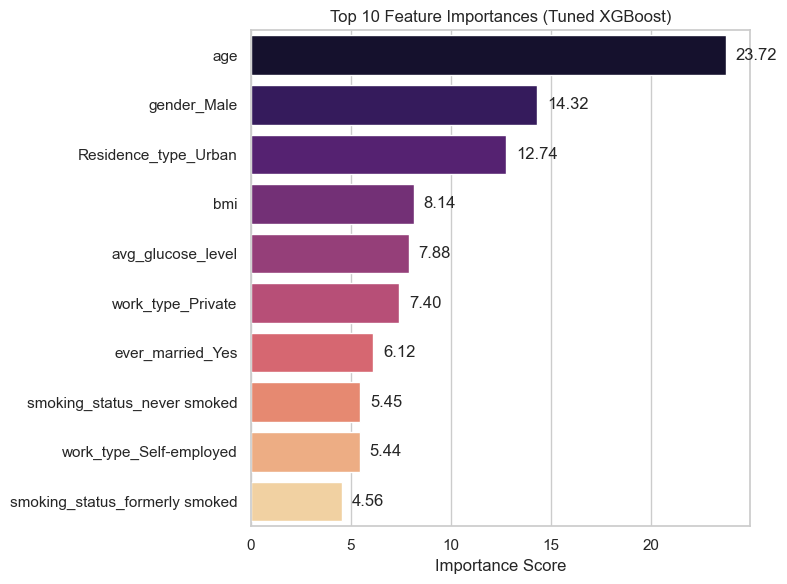

In [112]:
num_features = num_cols
cat_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)
feature_names = np.concatenate([num_features, cat_features])
importances = model.feature_importances_

feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})\
             .sort_values('importance', ascending=False).head(10)


sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))
ax = sns.barplot(x='importance', y='feature', data=feat_imp, palette='magma')
for p in ax.patches:
    ax.text(p.get_width()+0.5, p.get_y()+p.get_height()/2,
            f"{p.get_width():.2f}", va='center')
ax.set_title('Top 10 Feature Importances (Tuned XGBoost)')
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Best Threshold = 0.284, F1 = 0.217


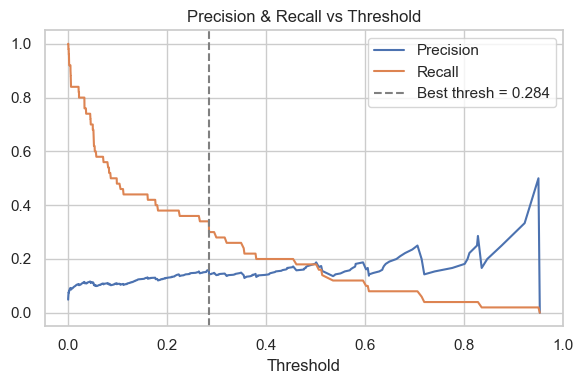

In [121]:
from sklearn.metrics import precision_recall_curve, f1_score

y_scores = best_xgb.predict_proba(XtestProc)[:, 1]


precisions, recalls, thresholds = precision_recall_curve(ytest, y_scores)


f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)


best_idx    = np.nanargmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1     = f1_scores[best_idx]

print(f"Best Threshold = {best_thresh:.3f}, F1 = {best_f1:.3f}")


plt.figure(figsize=(6,4))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1],    label="Recall")
plt.axvline(best_thresh, linestyle='--', color='gray', label=f"Best thresh = {best_thresh:.3f}")
plt.title("Precision & Recall vs Threshold")
plt.xlabel("Threshold")
plt.legend()
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:49:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:49:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC AUC после калибровки: 0.817


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:49:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


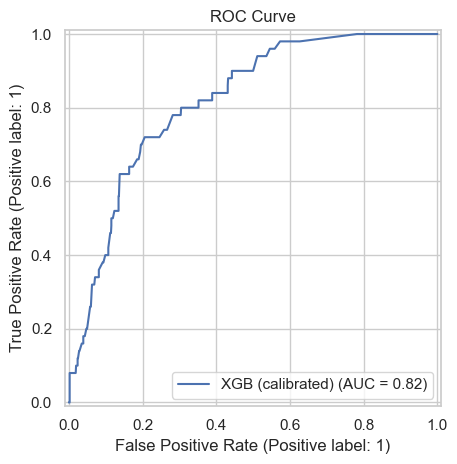

In [120]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics      import roc_auc_score

# Берём затюненный XGBoost best_xgb
calibrated = CalibratedClassifierCV(best_xgb, method='isotonic', cv=3)

# Обучаем на тех же препроцессированных данных
calibrated.fit(XtrainProc, ytrain)

# Проверяем ROC AUC уже на откалиброванных вероятностях
y_calibrated = calibrated.predict_proba(XtestProc)[:, 1]
print("ROC AUC после калибровки:", roc_auc_score(ytest, y_calibrated).round(3))



y_prob = calibrated.predict_proba(XtestProc)[:, 1]


fraction_of_positives, mean_predicted_value = calibration_curve(
    ytest, y_prob, n_bins=10, strategy='uniform'
)


RocCurveDisplay.from_estimator(calibrated, XtestProc, ytest, name="XGB (calibrated)")
plt.title("ROC Curve")
plt.tight_layout()
plt.show()


# 6 Model Exporting

In [ ]:
import joblib
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),      
    ('classifier', calibrated)          
])

# 2. Train on the full training set
final_pipeline.fit(Xtrain, ytrain)

# 3. Export to disk
joblib.dump(final_pipeline, "final_model.joblib")
print("Final pipeline saved as final_model.joblib")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:53:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:53:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Final pipeline saved as final_model.joblib


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:53:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


##  Conclusion: Feature Selection Experiment

We tested an XGBoost model trained on only the **top-5 most important features** (age, gender_Male, Residence_type_Urban, BMI, avg_glucose_level) and compared it to the full-feature model:

| Metric             | Full Model | Top-5 Features |
|--------------------|-----------:|---------------:|
| **Recall**         |     ~0.18  |         ~0.02  |
| **F1-score**       |     ~0.19  |         ~0.03  |
| **ROC AUC**        |     ~0.80  |         ~0.81  |
| **Accuracy**       |     ~0.92  |         ~0.94  |

- The **ROC AUC** and **accuracy** rise slightly when using only five features, but this is misleading:  
  - **Recall** collapses to near zero, meaning the model almost never detects true stroke cases.  
  - **F1-score** also drops dramatically, showing a loss of balance between precision and recall.

Basing on that, it is decided to leave all features
